Using device: cpu
Batch shape: torch.Size([64, 3, 32, 32]), labels shape: torch.Size([64])
Min pixel: -1.000, Max: 1.000

--- Running E1 ---
Epoch  1: Train Loss=1.6635, Acc=0.4096 | Val Loss=1.5250, Acc=0.4639
Epoch  2: Train Loss=1.4511, Acc=0.4882 | Val Loss=1.4553, Acc=0.4888
Epoch  3: Train Loss=1.3431, Acc=0.5260 | Val Loss=1.4233, Acc=0.5012
Epoch  4: Train Loss=1.2575, Acc=0.5583 | Val Loss=1.3834, Acc=0.5179
Epoch  5: Train Loss=1.1720, Acc=0.5859 | Val Loss=1.4156, Acc=0.5177
Epoch  6: Train Loss=1.1031, Acc=0.6072 | Val Loss=1.3953, Acc=0.5237
Epoch  7: Train Loss=1.0322, Acc=0.6346 | Val Loss=1.4415, Acc=0.5161
Epoch  8: Train Loss=0.9693, Acc=0.6574 | Val Loss=1.4409, Acc=0.5178
Epoch  9: Train Loss=0.8990, Acc=0.6796 | Val Loss=1.5099, Acc=0.5176
Epoch 10: Train Loss=0.8435, Acc=0.6998 | Val Loss=1.5397, Acc=0.5230
Epoch 11: Train Loss=0.7856, Acc=0.7199 | Val Loss=1.5796, Acc=0.5207
Epoch 12: Train Loss=0.7368, Acc=0.7373 | Val Loss=1.6479, Acc=0.5200
Epoch 13: Train Los

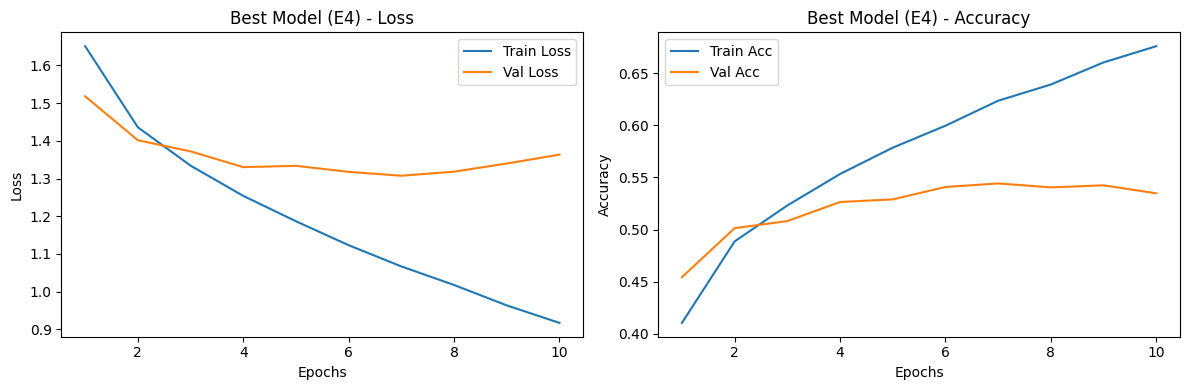

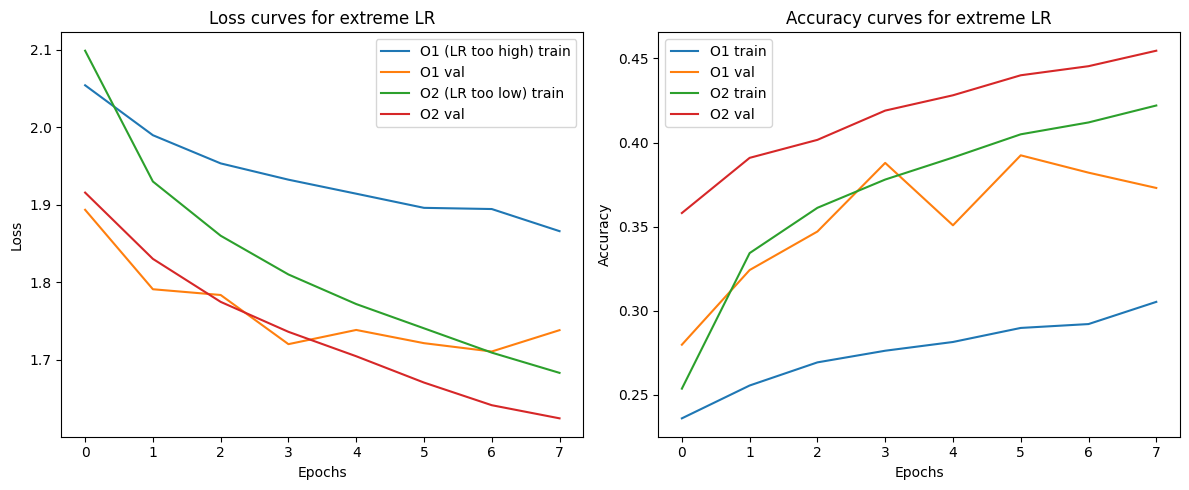

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import os
from copy import deepcopy

# Создаём папку для артефактов
os.makedirs("artifacts/figures", exist_ok=True)

# Фиксируем seed
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Выберите датасет: "KMNIST", "EMNIST" или "CIFAR10"
dataset_name = "CIFAR10"  # станет # или "CIFAR10"
batch_size = 64

# Трансформации
if dataset_name == "CIFAR10":
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
else:
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

# Загрузка
if dataset_name == "KMNIST":
    trainset = torchvision.datasets.KMNIST(root='./data', train=True, download=True, transform=transform)
    testset = torchvision.datasets.KMNIST(root='./data', train=False, download=True, transform=transform)
elif dataset_name == "EMNIST":
    trainset = torchvision.datasets.EMNIST(root='./data', split='balanced', train=True, download=True, transform=transform)
    testset = torchvision.datasets.EMNIST(root='./data', split='balanced', train=False, download=True, transform=transform)
elif dataset_name == "CIFAR10":
    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=transform)
    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=transform)
else:
    raise ValueError("Unknown dataset")

# Разбиение train/val
train_size = int(0.8 * len(trainset))
val_size = len(trainset) - train_size
train_idx, val_idx = torch.utils.data.random_split(
    range(len(trainset)), [train_size, val_size],
    generator=torch.Generator().manual_seed(seed)
)
train_dataset = Subset(trainset, train_idx)
val_dataset = Subset(trainset, val_idx)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False)

# Проверка
for images, labels in train_loader:
    print(f"Batch shape: {images.shape}, labels shape: {labels.shape}")
    print(f"Min pixel: {images.min():.3f}, Max: {images.max():.3f}")
    break

# Модель MLP
class MLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, num_classes,
                 dropout_prob=0.0, use_batchnorm=False, activation=nn.ReLU):
        super().__init__()
        layers = []
        prev_size = input_size
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_size, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(activation())
            if dropout_prob > 0:
                layers.append(nn.Dropout(dropout_prob))
            prev_size = h
        layers.append(nn.Linear(prev_size, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

# Функции обучения/оценки
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

# Параметры датасета
if dataset_name == "CIFAR10":
    input_size = 32*32*3
else:
    input_size = 28*28

num_classes = 10
if dataset_name == "EMNIST":
    num_classes = 47

hidden_sizes = [256, 128]

# Конфигурации экспериментов
experiments = {
    "E1": {
        "model_config": {"hidden_sizes": hidden_sizes, "dropout_prob": 0.0, "use_batchnorm": False},
        "optimizer": "Adam",
        "lr": 1e-3,
        "weight_decay": 0.0,
        "epochs": 15,
        "early_stopping": False
    },
    "E2": {
        "model_config": {"hidden_sizes": hidden_sizes, "dropout_prob": 0.3, "use_batchnorm": False},
        "optimizer": "Adam",
        "lr": 1e-3,
        "weight_decay": 0.0,
        "epochs": 15,
        "early_stopping": False
    },
    "E3": {
        "model_config": {"hidden_sizes": hidden_sizes, "dropout_prob": 0.0, "use_batchnorm": True},
        "optimizer": "Adam",
        "lr": 1e-3,
        "weight_decay": 0.0,
        "epochs": 15,
        "early_stopping": False
    },
    "O1": {
        "model_config": {"hidden_sizes": hidden_sizes, "dropout_prob": 0.3, "use_batchnorm": True},
        "optimizer": "Adam",
        "lr": 1e-1,
        "weight_decay": 0.0,
        "epochs": 8,
        "early_stopping": False
    },
    "O2": {
        "model_config": {"hidden_sizes": hidden_sizes, "dropout_prob": 0.3, "use_batchnorm": True},
        "optimizer": "Adam",
        "lr": 1e-5,
        "weight_decay": 0.0,
        "epochs": 8,
        "early_stopping": False
    },
    "O3": {
        "model_config": {"hidden_sizes": hidden_sizes, "dropout_prob": 0.3, "use_batchnorm": True},
        "optimizer": "SGD",
        "lr": 1e-2,
        "momentum": 0.9,
        "weight_decay": 1e-4,
        "epochs": 12,
        "early_stopping": False
    }
}

# Функция запуска эксперимента
def run_experiment(exp_id, config, device, train_loader, val_loader, test_loader=None):
    print(f"\n--- Running {exp_id} ---")
    model = MLP(
        input_size=input_size,
        hidden_sizes=config["model_config"]["hidden_sizes"],
        num_classes=num_classes,
        dropout_prob=config["model_config"]["dropout_prob"],
        use_batchnorm=config["model_config"]["use_batchnorm"]
    ).to(device)

    if config["optimizer"] == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
    elif config["optimizer"] == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=config["lr"],
                              momentum=config.get("momentum", 0),
                              weight_decay=config["weight_decay"])
    else:
        raise ValueError("Unknown optimizer")

    criterion = nn.CrossEntropyLoss()

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_acc = 0.0
    best_model_state = None
    patience_counter = 0
    epochs_trained = 0

    for epoch in range(1, config["epochs"] + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch:2d}: Train Loss={train_loss:.4f}, Acc={train_acc:.4f} | Val Loss={val_loss:.4f}, Acc={val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if config.get("early_stopping", False) and patience_counter >= 3:
                print(f"Early stopping triggered after {epoch} epochs")
                epochs_trained = epoch
                break

        epochs_trained = epoch

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    test_acc = None
    if test_loader is not None:
        _, test_acc = evaluate(model, test_loader, criterion, device)
        print(f"Test Accuracy: {test_acc:.4f}")

    results = {
        "experiment_id": exp_id,
        "dataset": dataset_name,
        "seed": seed,
        "model_summary": f"hidden={hidden_sizes}, dropout={config['model_config']['dropout_prob']}, batchnorm={config['model_config']['use_batchnorm']}",
        "optimizer": config["optimizer"],
        "lr": config["lr"],
        "momentum": config.get("momentum", ""),
        "weight_decay": config["weight_decay"],
        "epochs_trained": epochs_trained,
        "best_val_accuracy": best_val_acc,
        "best_val_loss": min(val_losses) if val_losses else None,
        "test_accuracy": test_acc
    }

    history = {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "train_acc": train_accs,
        "val_acc": val_accs
    }

    return model, results, history

# --- Часть A: эксперименты E1-E4 ---
all_results = []

# E1, E2, E3
for exp_id in ["E1", "E2", "E3"]:
    model, res, hist = run_experiment(exp_id, experiments[exp_id], device, train_loader, val_loader)
    all_results.append(res)

# Выбор лучшего регуляризованного
e2_res = next(r for r in all_results if r["experiment_id"] == "E2")
e3_res = next(r for r in all_results if r["experiment_id"] == "E3")
best_reg_exp_id = "E2" if e2_res["best_val_accuracy"] >= e3_res["best_val_accuracy"] else "E3"
print(f"Best regularized model: {best_reg_exp_id}")

# E4
e4_config = experiments[best_reg_exp_id].copy()
e4_config["early_stopping"] = True
e4_config["epochs"] = 30
experiments["E4"] = e4_config

model_e4, res_e4, hist_e4 = run_experiment("E4", e4_config, device,
                                           train_loader, val_loader, test_loader)
all_results.append(res_e4)

# Сохраняем лучшую модель и конфиг
torch.save(model_e4.state_dict(), "artifacts/best_model.pt")
best_config = {
    "experiment_id": "E4",
    "dataset": dataset_name,
    "seed": seed,
    "model_config": e4_config["model_config"],
    "optimizer": e4_config["optimizer"],
    "lr": e4_config["lr"],
    "weight_decay": e4_config["weight_decay"],
    "momentum": e4_config.get("momentum", None),
    "early_stopping_patience": 3,
    "best_val_accuracy": res_e4["best_val_accuracy"],
    "test_accuracy": res_e4["test_accuracy"]
}
with open("artifacts/best_config.json", "w") as f:
    json.dump(best_config, f, indent=2)

# --- Часть B: эксперименты O1-O3 ---
histories = {}
for exp_id in ["O1", "O2", "O3"]:
    model, res, hist = run_experiment(exp_id, experiments[exp_id], device, train_loader, val_loader)
    all_results.append(res)
    histories[exp_id] = hist

# Сохраняем сводную таблицу
df = pd.DataFrame(all_results)
df.to_csv("artifacts/runs.csv", index=False)
print(df)

# --- Графики ---
def plot_curves(history, title, filename):
    epochs = range(1, len(history["train_loss"])+1)
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.title(f"{title} - Loss")

    plt.subplot(1,2,2)
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"], label="Val Acc")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title(f"{title} - Accuracy")

    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

# График для лучшей модели
plot_curves(hist_e4, "Best Model (E4)", "artifacts/figures/curves_best.png")

# График для экстремальных LR (O1 и O2)
hist_o1 = histories["O1"]
hist_o2 = histories["O2"]

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(hist_o1["train_loss"], label="O1 (LR too high) train")
plt.plot(hist_o1["val_loss"], label="O1 val")
plt.plot(hist_o2["train_loss"], label="O2 (LR too low) train")
plt.plot(hist_o2["val_loss"], label="O2 val")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss curves for extreme LR")

plt.subplot(1,2,2)
plt.plot(hist_o1["train_acc"], label="O1 train")
plt.plot(hist_o1["val_acc"], label="O1 val")
plt.plot(hist_o2["train_acc"], label="O2 train")
plt.plot(hist_o2["val_acc"], label="O2 val")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy curves for extreme LR")

plt.tight_layout()
plt.savefig("artifacts/figures/curves_lr_extremes.png")
plt.show()